In [1]:
import os
import glob
import pandas as pd

base = os.path.expanduser("~/IDX-Exchange-Internship-Data_Science-Summer2026/california")

files = glob.glob(os.path.join(base, "CRMLSSold*.csv"))

print("Base folder:", base)
print("Folder exists:", os.path.exists(base))
print("Files found:", len(files))
print(files[:5])

Base folder: /Users/nguyenanh/IDX-Exchange-Internship-Data_Science-Summer2026/california
Folder exists: True
Files found: 30
['/Users/nguyenanh/IDX-Exchange-Internship-Data_Science-Summer2026/california/CRMLSSold202404_filled.csv', '/Users/nguyenanh/IDX-Exchange-Internship-Data_Science-Summer2026/california/CRMLSSold202409.csv', '/Users/nguyenanh/IDX-Exchange-Internship-Data_Science-Summer2026/california/CRMLSSold202408.csv', '/Users/nguyenanh/IDX-Exchange-Internship-Data_Science-Summer2026/california/CRMLSSold202501_filled.csv', '/Users/nguyenanh/IDX-Exchange-Internship-Data_Science-Summer2026/california/CRMLSSold20220101_20231231_filled.csv']


In [2]:
# Load all files
dfs = []
for f in sorted(files):
    temp = pd.read_csv(f, low_memory=False)
    temp["_source_file"] = os.path.basename(f)  # track which file each row came from
    print(f"{os.path.basename(f):50s} → {len(temp):>8,} rows, {temp.shape[1]} cols")
    dfs.append(temp)

df_raw = pd.concat(dfs, ignore_index=True)
print(f"\nTotal rows: {len(df_raw):,}")
print(f"Total columns: {df_raw.shape[1]}")

CRMLSSold20220101_20231231_filled.csv              →  157,828 rows, 81 cols
CRMLSSold202401_filled.csv                         →   17,958 rows, 81 cols
CRMLSSold202402_filled.csv                         →   19,925 rows, 81 cols
CRMLSSold202403_filled.csv                         →   23,276 rows, 81 cols
CRMLSSold202404_filled.csv                         →   24,640 rows, 81 cols
CRMLSSold202405_filled.csv                         →   26,487 rows, 81 cols
CRMLSSold202406_filled.csv                         →   24,328 rows, 81 cols
CRMLSSold202407_filled.csv                         →   26,240 rows, 81 cols
CRMLSSold202408.csv                                →   24,558 rows, 79 cols
CRMLSSold202409.csv                                →   21,267 rows, 79 cols
CRMLSSold202410.csv                                →   23,274 rows, 79 cols
CRMLSSold202411.csv                                →   20,279 rows, 79 cols
CRMLSSold202412.csv                                →   20,241 rows, 79 cols
CRMLSSold202

In [3]:
df_raw["_source_file"].head()

0    CRMLSSold20220101_20231231_filled.csv
1    CRMLSSold20220101_20231231_filled.csv
2    CRMLSSold20220101_20231231_filled.csv
3    CRMLSSold20220101_20231231_filled.csv
4    CRMLSSold20220101_20231231_filled.csv
Name: _source_file, dtype: object

In [4]:
df_raw.head()

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,_source_file,BuyerAgentAOR,ListAgentAOR
0,"Carpet,Wood",True,NaN,NaN,True,98000.0,556366533,michellefsellsoc@gmail.com,2022-02-25,95000.0,...,ABC Unified,92708,0.0,NaN,NaN,False,False,CRMLSSold20220101_20231231_filled.csv,NaN,NaN
1,NaN,False,NaN,NaN,False,1200.0,556366530,dineshcalre@gmail.com,2022-02-19,1200.0,...,Apple Valley Unified,92308,0.0,43000.0,NaN,False,False,CRMLSSold20220101_20231231_filled.csv,NaN,NaN
2,NaN,True,NaN,NaN,False,1100000.0,556366044,cindydavishomes@gmail.com,2022-04-15,1100000.0,...,Solana Beach,92075,370.0,NaN,NaN,False,False,CRMLSSold20220101_20231231_filled.csv,NaN,NaN
3,NaN,True,NaN,NaN,False,2499999.0,556365765,bryanmeathe@gmail.com,2022-01-04,2499999.0,...,Carlsbad Unified,92008,140.0,13376.0,NaN,False,False,CRMLSSold20220101_20231231_filled.csv,NaN,NaN
4,"Carpet,Tile",NaN,NaN,NaN,NaN,598888.0,556365290,steven@westsideres.com,2022-01-12,640000.0,...,Other,95111,300.0,2738.0,NaN,False,False,CRMLSSold20220101_20231231_filled.csv,NaN,NaN


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 794271 entries, 0 to 794270
Data columns (total 83 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Flooring                      465886 non-null  object 
 1   ViewYN                        707277 non-null  object 
 2   WaterfrontYN                  434 non-null     object 
 3   BasementYN                    13172 non-null   object 
 4   PoolPrivateYN                 690017 non-null  object 
 5   OriginalListPrice             791935 non-null  float64
 6   ListingKey                    794271 non-null  int64  
 7   ListAgentEmail                792478 non-null  object 
 8   CloseDate                     794271 non-null  object 
 9   ClosePrice                    794263 non-null  float64
 10  ListAgentFirstName            789394 non-null  object 
 11  ListAgentLastName             794180 non-null  object 
 12  Latitude                      793455 non-nul

In [6]:
df_raw[["ClosePrice", "OriginalListPrice", "LivingArea", "BedroomsTotal", 
        "BathroomsTotalInteger", "DaysOnMarket", "YearBuilt"]].describe()

,ClosePrice,OriginalListPrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,DaysOnMarket,YearBuilt
count,7.942630e+05,7.919350e+05,7.366580e+05,739759.000000,755771.00000,794270.000000,759347.000000
mean,8.675752e+05,9.027827e+05,5.539220e+03,3.077731,2.44057,42.427458,1977.914961
std,5.044244e+06,5.827031e+06,1.834682e+06,1.374562,1.38339,75.919275,26.998957
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.00000,-288.000000,1776.000000
25%,5.127500e+04,6.499900e+04,1.183000e+03,2.000000,2.00000,8.000000,1959.000000
50%,6.250000e+05,6.330000e+05,1.579000e+03,3.000000,2.00000,20.000000,1979.000000
75%,1.060000e+06,1.074900e+06,2.149000e+03,4.000000,3.00000,50.000000,1999.000000
max,9.895000e+08,1.390000e+09,9.090991e+08,180.000000,175.00000,12430.000000,2026.000000


In [7]:
df_raw.isna().sum().sort_values(ascending=False).head(20)

CoveredSpaces                   794271
AboveGradeFinishedArea          794271
FireplacesTotal                 794271
MiddleOrJuniorSchoolDistrict    794271
ElementarySchoolDistrict        794271
WaterfrontYN                    793837
TaxYear                         793773
BusinessType                    792013
BelowGradeFinishedArea          790928
TaxAnnualAmount                 790912
BasementYN                      781099
BuilderName                     764093
LotSizeDimensions               752083
CoBuyerAgentFirstName           730015
ElementarySchool                704646
MiddleOrJuniorSchool            703918
BuildingAreaTotal               693048
HighSchool                      677564
CoListAgentFirstName            631672
CoListAgentLastName             631351
dtype: int64

In [8]:
df_raw["ClosePrice"].isna().sum()

np.int64(8)

In [9]:
df_raw["ListingKey"].duplicated().sum()

np.int64(646)

In [10]:
# Check column consistency across files
col_sets = {os.path.basename(f): set(d.columns) for f, d in zip(sorted(files), dfs)}
all_cols = set.union(*col_sets.values())

print(f"Total unique columns across all files: {len(all_cols)}\n")

any_mismatch = False
for fname, cols in col_sets.items():
    missing = all_cols - cols
    extra   = cols - all_cols  # won't happen but good to check
    if missing:
        any_mismatch = True
        print(f"⚠️  {fname} MISSING {len(missing)} cols: {missing}")

if not any_mismatch:
    print("✅ All files have identical columns — clean concat!")

Total unique columns across all files: 83

⚠️  CRMLSSold20220101_20231231_filled.csv MISSING 2 cols: {'ListAgentAOR', 'BuyerAgentAOR'}
⚠️  CRMLSSold202401_filled.csv MISSING 2 cols: {'ListAgentAOR', 'BuyerAgentAOR'}
⚠️  CRMLSSold202402_filled.csv MISSING 2 cols: {'ListAgentAOR', 'BuyerAgentAOR'}
⚠️  CRMLSSold202403_filled.csv MISSING 2 cols: {'ListAgentAOR', 'BuyerAgentAOR'}
⚠️  CRMLSSold202404_filled.csv MISSING 2 cols: {'ListAgentAOR', 'BuyerAgentAOR'}
⚠️  CRMLSSold202405_filled.csv MISSING 2 cols: {'BuyerAgencyCompensation', 'BuyerAgencyCompensationType'}
⚠️  CRMLSSold202406_filled.csv MISSING 2 cols: {'BuyerAgencyCompensation', 'BuyerAgencyCompensationType'}
⚠️  CRMLSSold202407_filled.csv MISSING 2 cols: {'BuyerAgencyCompensation', 'BuyerAgencyCompensationType'}
⚠️  CRMLSSold202408.csv MISSING 4 cols: {'latfilled', 'BuyerAgencyCompensation', 'BuyerAgencyCompensationType', 'lonfilled'}
⚠️  CRMLSSold202409.csv MISSING 4 cols: {'latfilled', 'BuyerAgencyCompensation', 'BuyerAgencyCompe

In [11]:
# Week 1 sanity check — just confirm data loaded correctly
print(f"Rows:    {len(df_raw):,}")
print(f"Columns: {df_raw.shape[1]}")
print(f"\nColumn names:")
print(list(df_raw.columns))

Rows:    794,271
Columns: 83

Column names:
['Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City', 'BuyerAgencyCompensation', 'TaxYear', 'BuildingAreaTotal

In [12]:
for i, col in enumerate(df_raw.columns, start=1):
    print(i, col)

1 Flooring
2 ViewYN
3 WaterfrontYN
4 BasementYN
5 PoolPrivateYN
6 OriginalListPrice
7 ListingKey
8 ListAgentEmail
9 CloseDate
10 ClosePrice
11 ListAgentFirstName
12 ListAgentLastName
13 Latitude
14 Longitude
15 UnparsedAddress
16 PropertyType
17 LivingArea
18 ListPrice
19 DaysOnMarket
20 ListOfficeName
21 BuyerOfficeName
22 CoListOfficeName
23 ListAgentFullName
24 CoListAgentFirstName
25 CoListAgentLastName
26 BuyerAgentMlsId
27 BuyerAgentFirstName
28 BuyerAgentLastName
29 FireplacesTotal
30 AssociationFeeFrequency
31 AboveGradeFinishedArea
32 ListingKeyNumeric
33 MLSAreaMajor
34 TaxAnnualAmount
35 CountyOrParish
36 MlsStatus
37 ElementarySchool
38 AttachedGarageYN
39 ParkingTotal
40 BuilderName
41 PropertySubType
42 LotSizeAcres
43 SubdivisionName
44 BuyerOfficeAOR
45 YearBuilt
46 BuyerAgencyCompensationType
47 StreetNumberNumeric
48 ListingId
49 BathroomsTotalInteger
50 City
51 BuyerAgencyCompensation
52 TaxYear
53 BuildingAreaTotal
54 BedroomsTotal
55 ContractStatusChangeDate
56 Ele

In [13]:

# CRMLS key column dictionary
column_meanings = {
    # --- Price & sale outcome ---
    "ClosePrice":            "Final sale price (main target variable)",
    "ListPrice":             "Most recent list price",
    "OriginalListPrice":     "Price the property was first listed at",
    "DaysOnMarket":          "Days active before going under contract",
    # --- Property characteristics ---
    "PropertyType":          "Top-level type (Residential, Commercial, Land…)",
    "PropertySubType":       "Detailed type (Single Family Residence, Condominium…)",
    "LivingArea":            "Finished living area (sq ft)",
    "LotSizeSquareFeet":     "Lot size in square feet",
    "BedroomsTotal":         "Total bedrooms",
    "BathroomsTotalInteger": "Total bathrooms (whole number)",
    "YearBuilt":             "Year built",
    "Stories":               "Number of stories",
    "GarageSpaces":          "Garage parking spaces",
    "PoolPrivateYN":         "Has a private pool (Yes/No)",
    "ViewYN":                "Has a view (Yes/No)",
    "FireplacesTotal":       "Number of fireplaces",
    "NewConstructionYN":     "New construction (Yes/No)",
    # --- Location ---
    "City":                  "City",
    "PostalCode":            "ZIP code",
    "CountyOrParish":        "County",
    "Latitude":              "Property latitude",
    "Longitude":             "Property longitude",
    "UnparsedAddress":       "Full street address",
    "MLSAreaMajor":          "Major MLS geographic area",
    # --- Costs / taxes ---
    "TaxAnnualAmount":       "Annual property tax",
    "AssociationFee":        "HOA fee amount",
    "AssociationFeeFrequency": "HOA fee billing frequency (Monthly, Annually…)",
    # --- Timing ---
    "CloseDate":             "Date the sale closed",
    "ListingContractDate":   "Date listed for sale",
    "PurchaseContractDate":  "Date the offer was accepted (went into escrow)",
    # --- Identifiers ---
    "ListingId":             "Human-readable MLS listing number",
    "ListingKey":            "Unique system ID for the listing record",
}

col_dict = pd.DataFrame(column_meanings.items(), columns=["Column", "Meaning"])



In [14]:
col_dict["In data"]   = col_dict["Column"].isin(df_raw.columns)
col_dict["Non-null %"] = col_dict["Column"].map(
    lambda c: round(df_raw[c].notna().mean() * 100, 1) if c in df_raw.columns else None
)
col_dict


,Column,Meaning,In data,Non-null %
0,ClosePrice,Final sale price (main target variable),True,100.0
1,ListPrice,Most recent list price,True,99.8
2,OriginalListPrice,Price the property was first listed at,True,99.7
3,DaysOnMarket,Days active before going under contract,True,100.0
4,PropertyType,"Top-level type (Residential, Commercial, Land…)",True,100.0
5,PropertySubType,"Detailed type (Single Family Residence, Condom...",True,92.1
6,LivingArea,Finished living area (sq ft),True,92.7
7,LotSizeSquareFeet,Lot size in square feet,True,90.7
8,BedroomsTotal,Total bedrooms,True,93.1
9,BathroomsTotalInteger,Total bathrooms (whole number),True,95.2


### Week 1 Dataset Sanity Check

I successfully loaded the California CRMLS Sold dataset into Python. The combined dataset contains 794,271 rows and 83 columns, which confirms that the files were accessed and combined correctly.

The dataset includes important columns for price prediction, such as `ClosePrice`, `OriginalListPrice`, `LivingArea`, `BedroomsTotal`, `BathroomsTotalInteger`, `DaysOnMarket`, `YearBuilt`, `PropertyType`, `Latitude`, `Longitude`, `CloseDate`, and `ListingKey`.

The target variable for the project is likely `ClosePrice`, which represents the final sale price of the property. This column is mostly complete, with only 8 missing values out of 794,271 rows.

I also found some data quality issues that will need to be handled later. Some numeric columns contain unrealistic or invalid values, such as `ClosePrice` equal to 0, `OriginalListPrice` equal to 0, `LivingArea` equal to 0, negative `DaysOnMarket`, and unusually high bedroom or bathroom counts. These values should be cleaned before modeling.

There are also 646 duplicate `ListingKey` values, which means some listings appear more than once. These duplicates should be removed during the cleaning stage.

Some columns have many missing values, including `CoveredSpaces`, `AboveGradeFinishedArea`, `FireplacesTotal`, school district columns, `WaterfrontYN`, `TaxYear`, `BusinessType`, and `BasementYN`. These columns may not be useful for the first version of the model unless they are cleaned carefully.

Overall, the dataset was loaded successfully and contains the main features needed to begin exploratory data analysis and cleaning.

In [15]:
df_raw["PropertyType"].value_counts()

PropertyType
Residential            532920
ResidentialLease       181556
Land                    27429
ManufacturedInPark      21429
ResidentialIncome       21015
CommercialSale           5164
CommercialLease          4205
BusinessOpportunity       552
Resid                       1
Name: count, dtype: int64

In [16]:
df_raw["PropertySubType"].value_counts()

PropertySubType
SingleFamilyResidence    484815
Condominium              137769
Townhouse                 45583
Apartment                 17822
Duplex                    14860
ManufacturedOnLand         8058
Triplex                    4560
Quadruplex                 4537
StockCooperative           2681
MixedUse                   2609
Office                     2235
Retail                     1478
Industrial                  931
Cabin                       648
Studio                      570
Business                    533
Warehouse                   380
RoomingHouse                376
SpecialPurpose              215
MultiFamily                 183
BoatSlip                    149
Agriculture                 123
OwnYourOwn                  112
UnimprovedLand              102
Loft                        100
MobileHome                   96
WaterPositionWithLand        93
ManufacturedHome             68
Farm                         30
Timeshare                    29
HotelMotel              

In [17]:
df = df_raw[
    (df_raw["PropertyType"] == "Residential") &
    (df_raw["PropertySubType"] == "SingleFamilyResidence")
].copy()

print(f"Rows before filter: {len(df_raw):,}")
print(f"Rows after filter:  {len(df):,}")

Rows before filter: 794,271
Rows after filter:  399,157


In [18]:
df_raw[df_raw["PropertySubType"] == "SingleFamilyResidence"]["PropertyType"].value_counts()

PropertyType
Residential          399157
ResidentialLease      84637
ResidentialIncome      1020
CommercialSale            1
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

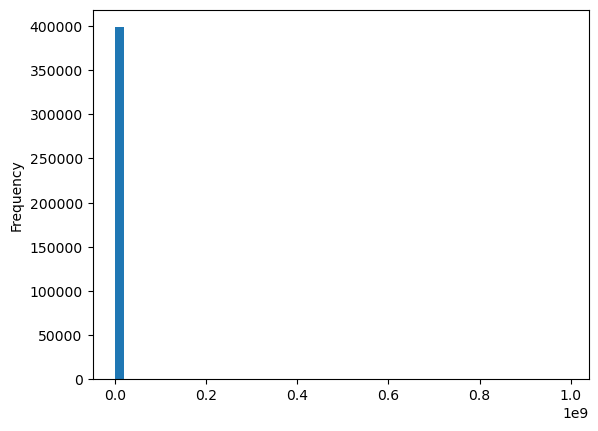

In [19]:
df["ClosePrice"].plot(kind="hist", bins=50)

In [20]:
df["ClosePrice"].quantile([0.999, 0.9995, 0.9999, 0.99995, 1.0])

0.99900    1.700000e+07
0.99950    2.300000e+07
0.99990    4.750000e+07
0.99995    1.785076e+08
1.00000    9.895000e+08
Name: ClosePrice, dtype: float64

In [21]:
df["ClosePrice"] <= 50_000_000

3         True
6         True
7         True
12        True
14        True
          ... 
794237    True
794239    True
794247    True
794249    True
794267    True
Name: ClosePrice, Length: 399157, dtype: bool

In [22]:
(df["ClosePrice"] > 50_000_000).sum()

np.int64(36)

In [23]:
(df["ClosePrice"] == 0).sum()

np.int64(1)

In [24]:
df["ClosePrice"].quantile([0.0, 0.0001, 0.0005, 0.001, 0.005, 0.01])


0.0000         0.00
0.0001     26732.32
0.0005     66000.00
0.0010     94077.00
0.0050    189000.00
0.0100    235000.00
Name: ClosePrice, dtype: float64

In [25]:
df[df["ClosePrice"] < 30000][["ClosePrice", "LivingArea", "BedroomsTotal", "City", "CloseDate"]].sort_values("ClosePrice")

,ClosePrice,LivingArea,BedroomsTotal,City,CloseDate
565002,0.00,2001.0,4.0,Temple City,2025-07-30
428415,1.15,1811.0,4.0,West Hills,2024-12-09
700996,1.75,3513.0,3.0,Palm Desert,2026-01-30
266525,345.00,2048.0,2.0,Brentwood,2024-05-15
361770,380.00,1200.0,3.0,Desert Hot Springs,2024-09-03
637876,485.00,1305.0,3.0,Cathedral City,2025-10-23
765202,685.00,2980.0,5.0,Oakley,2026-04-29
20092,2750.00,1792.0,3.0,Desert Hot Springs,2023-11-07
67985,6000.00,NaN,3.0,NaN,2023-09-05
717696,8000.00,984.0,3.0,Trona,2026-02-04


In [26]:
[c for c in df_raw.columns if "condition" in c.lower() or "special" in c.lower() or "compensation" in c.lower()]

['BuyerAgencyCompensationType', 'BuyerAgencyCompensation']

In [27]:
price_min = 15_000
price_max = 50_000_000

before = len(df)
df = df[(df["ClosePrice"] >= price_min) & (df["ClosePrice"] <= price_max)].copy()
after = len(df)

print(f"Rows before ClosePrice cleaning: {before:,}")
print(f"Rows after ClosePrice cleaning:  {after:,}")
print(f"Rows removed: {before - after:,}")

Rows before ClosePrice cleaning: 399,157
Rows after ClosePrice cleaning:  399,102
Rows removed: 55


ClosePrice cleaning: Removed 55 rows (0.01%) outside the range $15,000–$50,000,000. Below $15K, values included $0 and near-zero prices attached to normal-sized homes (e.g., $1.15 for a 4-bed/2000sqft house) — not real market prices, and possibly non-arms-length transactions we couldn't confirm from available columns. Above $50M, values jumped erratically (a 4-5x gap between adjacent percentiles) suggesting data entry errors rather than real luxury sales.


In [28]:
df[df["DaysOnMarket"] < 0][["ListingContractDate", "PurchaseContractDate", "DaysOnMarket", "City"]].sort_values("DaysOnMarket").head(20)


,ListingContractDate,PurchaseContractDate,DaysOnMarket,City
669830,2024-01-12,2025-07-07,-265.0,Ontario
85917,2023-07-20,2023-08-14,-129.0,La Quinta
289439,2024-03-26,2024-06-03,-84.0,San Jacinto
118543,2023-06-07,2023-06-09,-67.0,Oxnard
75742,2023-05-09,2023-05-31,-66.0,Arcadia
9394,2021-06-07,2021-11-28,-66.0,Lancaster
983,2021-10-07,2022-01-25,-65.0,Glendora
669815,2024-02-08,2025-07-08,-65.0,Los Angeles
580255,2025-02-12,2025-07-15,-63.0,California City
2063,2021-10-01,2022-09-26,-61.0,Indio


In [29]:
[c for c in df_raw.columns if "list" in c.lower() and "date" in c.lower()]

['ListingContractDate']

In [30]:
(df["DaysOnMarket"] < 0).sum()

np.int64(87)

In [31]:
before_bad = (df["DaysOnMarket"] < 0).sum()
df.loc[df["DaysOnMarket"] < 0, "DaysOnMarket"] = None

after_bad = (df["DaysOnMarket"] < 0).sum()
print(f"Negative DaysOnMarket before: {before_bad}")
print(f"Negative DaysOnMarket after:  {after_bad}")
print(f"Missing DaysOnMarket now:     {df['DaysOnMarket'].isna().sum()}")

Negative DaysOnMarket before: 87
Negative DaysOnMarket after:  0
Missing DaysOnMarket now:     87


#### DaysOnMarket Cleaning

Found 87 rows (0.02%) with negative `DaysOnMarket` values (as low as -265), which is 
impossible since DaysOnMarket represents a duration and cannot be negative.

Checked the raw `ListingContractDate` and `PurchaseContractDate` for these rows to see 
if the dates were simply reversed — they were not. In every case checked, the purchase 
date correctly came after the listing date, so the negative value isn't explained by a 
date-order error. No additional "original listing date" column exists in this dataset 
to explain the discrepancy, so the root cause is likely an internal MLS calculation 
quirk (e.g., relisted properties) that can't be reverse-engineered from the fields 
available here.

**Decision:** rather than dropping these 87 rows outright, `DaysOnMarket` was set to 
missing (NaN) only for the affected rows, since `DaysOnMarket` is a feature (not the 
target variable). The rest of each row — including `ClosePrice`, `LivingArea`, 
`BedroomsTotal`, etc. — is still valid and useful for training, so there's no reason 
to discard it over one broken feature. The resulting missing values will be handled 
during imputation along with other missing data.

**General rule applied:** a bad value in the target column (`ClosePrice`) means the 
whole row should be dropped, since nothing is salvageable. A bad value in a feature 
column means only that value should be nulled out, preserving the rest of the row.

In [32]:
df["BedroomsTotal"].quantile([0.99, 0.999, 0.9995, 0.9999, 1.0])

0.9900     6.0
0.9990     8.0
0.9995     9.0
0.9999    11.0
1.0000    45.0
Name: BedroomsTotal, dtype: float64

In [33]:
df["BathroomsTotalInteger"].quantile([0.99, 0.999, 0.9995, 0.9999, 1.0])

0.9900      6.0
0.9990     10.0
0.9995     11.0
0.9999     14.0
1.0000    175.0
Name: BathroomsTotalInteger, dtype: float64

In [34]:
df[df["BedroomsTotal"] > 11][["BedroomsTotal", "BathroomsTotalInteger", "LivingArea", "ClosePrice", "City"]].sort_values("BedroomsTotal", ascending=False).head(15)

,BedroomsTotal,BathroomsTotalInteger,LivingArea,ClosePrice,City
490315,45.0,45.0,10248.0,1600000.0,Los Angeles
272056,34.0,5.0,4060.0,2050000.0,Coto de Caza
450303,31.0,22.0,12078.0,3800000.0,Downey
694608,22.0,18.0,5814.0,1200000.0,Los Angeles
137945,22.0,2.0,1064.0,620000.0,Anaheim
669284,19.0,23.0,31068.0,28000000.0,Rancho Santa Fe
511821,17.0,15.0,13000.0,1950000.0,Julian
689907,16.0,11.0,8305.0,2555000.0,Granada Hills
611200,16.0,16.0,8421.0,1075000.0,Los Angeles
449841,15.0,12.0,8200.0,2150000.0,Whittier


In [35]:
df["sqft_per_bedroom"] = df["LivingArea"] / df["BedroomsTotal"]
df["sqft_per_bedroom"].describe()

/Users/nguyenanh/miniforge3/envs/dsc80/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    398858.00
mean           inf
std            NaN
min           0.00
25%         445.25
50%         539.20
75%         663.00
max            inf
Name: sqft_per_bedroom, dtype: float64

In [36]:
(df["BedroomsTotal"] == 0).sum()

np.int64(222)

In [37]:
df[df["BedroomsTotal"] == 0][["BedroomsTotal", "BathroomsTotalInteger", "LivingArea", "ClosePrice", "City"]].head(15)

,BedroomsTotal,BathroomsTotalInteger,LivingArea,ClosePrice,City
161,0.0,1.0,312.0,68995.0,NaN
2376,0.0,0.0,396.0,2000000.0,Encinitas
5651,0.0,1.0,400.0,170000.0,29 Palms
7435,0.0,1.0,352.0,169000.0,Running Springs
9540,0.0,1.0,400.0,69000.0,29 Palms
11137,0.0,0.0,100.0,2000000.0,Murrieta
11341,0.0,0.0,400.0,88000.0,Landers
12547,0.0,NaN,448.0,315000.0,Rialto
15078,0.0,2.0,4496.0,915000.0,Moorpark
17802,0.0,1.0,459.0,770000.0,San Diego


In [38]:
zero_bed = df[df["BedroomsTotal"] == 0].copy()
zero_bed["price_per_sqft"] = zero_bed["ClosePrice"] / zero_bed["LivingArea"]
zero_bed[["LivingArea", "ClosePrice", "price_per_sqft", "City"]].sort_values("price_per_sqft", ascending=False).head(15)

,LivingArea,ClosePrice,price_per_sqft,City
691205,0.0,650000.0,inf,San Diego
450810,0.0,550000.0,inf,Altadena
472934,0.0,520000.0,inf,Altadena
470744,0.0,560000.0,inf,Altadena
470082,0.0,550000.0,inf,Altadena
468499,0.0,745000.0,inf,Altadena
620786,0.0,3475000.0,inf,West Hollywood
451142,0.0,550000.0,inf,Altadena
427645,0.0,375000.0,inf,Napa
490062,0.0,700000.0,inf,Altadena


In [39]:
zero_bed_nonzero_area = zero_bed[zero_bed["LivingArea"] > 0]
zero_bed_nonzero_area[["LivingArea", "ClosePrice", "price_per_sqft", "City"]].sort_values("price_per_sqft", ascending=False).head(15)

,LivingArea,ClosePrice,price_per_sqft,City
430192,100.0,6000000.0,60000.000000,Hermosa Beach
31653,100.0,6000000.0,60000.000000,Malibu
11137,100.0,2000000.0,20000.000000,Murrieta
151440,100.0,1850000.0,18500.000000,Beverly Hills
531969,100.0,1640000.0,16400.000000,Manhattan Beach
430186,600.0,7250000.0,12083.333333,Dana Point
40731,100.0,785000.0,7850.000000,Sun Valley
666339,100.0,605000.0,6050.000000,Altadena
437891,300.0,1750000.0,5833.333333,Costa Mesa
658057,630.0,3250000.0,5158.730159,Newport Beach


In [40]:
(zero_bed["LivingArea"] == 0).sum()

np.int64(40)

In [46]:
df["price_per_sqft"] = df["ClosePrice"] / df["LivingArea"]
(df["price_per_sqft"] > 3000).sum()

np.int64(774)

In [47]:
high_ppsf = df[df["price_per_sqft"] > 3000].copy()
high_ppsf["price_per_sqft"].describe()

/Users/nguyenanh/miniforge3/envs/dsc80/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count     774.000000
mean             inf
std              NaN
min      3003.141361
25%      3326.725724
50%      4009.114884
75%      6919.298407
max              inf
Name: price_per_sqft, dtype: float64

In [48]:
high_ppsf[["LivingArea", "BedroomsTotal", "ClosePrice", "price_per_sqft", "City"]].sort_values("price_per_sqft", ascending=False).head(20)

,LivingArea,BedroomsTotal,ClosePrice,price_per_sqft,City
1252,0.0,4.0,7680000.0,inf,Studio City
342704,0.0,3.0,2134500.0,inf,Malibu
344512,0.0,6.0,17000000.0,inf,Los Angeles
359754,0.0,4.0,5675000.0,inf,Beverly Hills
368462,0.0,0.0,2545026.0,inf,Los Angeles
371920,0.0,3.0,1200000.0,inf,Oakland
374440,0.0,3.0,1000000.0,inf,Los Angeles
376716,0.0,4.0,2950000.0,inf,Los Angeles
381506,0.0,0.0,1900000.0,inf,Los Angeles
389011,0.0,3.0,4150000.0,inf,Los Angeles


In [41]:
(df["LivingArea"] == 0).sum()

np.int64(158)

In [42]:
valid_area = df[df["LivingArea"] > 0].copy()
valid_area["price_per_sqft"] = valid_area["ClosePrice"] / valid_area["LivingArea"]
valid_area["price_per_sqft"].quantile([0.99, 0.999, 0.9995, 0.9999, 1.0])

0.9900      1936.654450
0.9990      3389.829930
0.9995      4226.842095
0.9999      6707.775452
1.0000    475000.000000
Name: price_per_sqft, dtype: float64

In [43]:
# 1. LivingArea == 0 → null out (feature, not target; bedrooms/price often still valid)
df.loc[df["LivingArea"] == 0, "LivingArea"] = None

# 2. Recompute price_per_sqft cleanly now that LivingArea==0 rows are handled
df["price_per_sqft"] = df["ClosePrice"] / df["LivingArea"]

# 3. Drop rows that are almost certainly land/teardown sales, not real homes
before = len(df)
df = df[(df["price_per_sqft"].isna()) | (df["price_per_sqft"] <= 10000)].copy()
after = len(df)

print(f"Rows before price_per_sqft cleaning: {before:,}")
print(f"Rows after price_per_sqft cleaning:  {after:,}")
print(f"Rows removed: {before - after:,}")

Rows before price_per_sqft cleaning: 399,102
Rows after price_per_sqft cleaning:  399,088
Rows removed: 14
